# Exercise 1: Compute pi on the GPU

## Tasks

1. Write a CPU-program that computes pi using geometry and statistics
2. Port this program to the GPU
3. Optimize

## Solution

<-- see `compute_pi_solution.ipynb`

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time

## Función CPU

In [13]:
def compute_pi_cpu(n_points):
    inside = 0

    for _ in range(n_points):
        x = np.random.uniform(-1.0, 1.0)
        y = np.random.uniform(-1.0, 1.0)

        if x*x + y*y <= 1.0:
            inside += 1

    pi_estimate = 4.0 * inside / n_points

    return pi_estimate, inside

## Ejecución CPU

In [14]:
n_points = 1_000_000

start = time.time()

pi_cpu, inside_cpu = compute_pi_cpu(n_points)

end = time.time()

print("CPU result")
print("Points:", n_points)
print("Inside circle:", inside_cpu)
print("Estimated pi:", pi_cpu)
print("Real pi:", np.pi)
print("Error:", abs(np.pi - pi_cpu))
print("CPU time:", end - start, "seconds")

CPU result
Points: 1000000
Inside circle: 784900
Estimated pi: 3.1396
Real pi: 3.141592653589793
Error: 0.0019926535897929476
CPU time: 3.6924664974212646 seconds


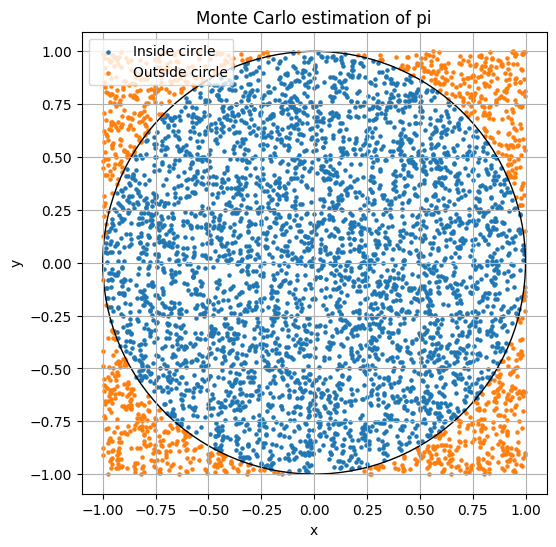

In [15]:
n_plot = 5000

x = np.random.uniform(-1.0, 1.0, n_plot)
y = np.random.uniform(-1.0, 1.0, n_plot)

inside = x*x + y*y <= 1.0

plt.figure(figsize=(6, 6))

plt.scatter(x[inside], y[inside], s=5, label="Inside circle")
plt.scatter(x[~inside], y[~inside], s=5, label="Outside circle")

circle = plt.Circle((0, 0), 1.0, fill=False)
plt.gca().add_patch(circle)

plt.title("Monte Carlo estimation of pi")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.grid(True)

plt.show()

## Imports PyCUDA

In [16]:
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule

## Basic CUDA kernel

In [17]:
kernel_code = """
__global__ void count_inside(float *x, float *y, int *inside, int n)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if (i < n)
    {
        float dist = x[i] * x[i] + y[i] * y[i];

        if (dist <= 1.0f)
        {
            inside[i] = 1;
        }
        else
        {
            inside[i] = 0;
        }
    }
}
"""

In [18]:
mod = SourceModule(kernel_code)
count_inside = mod.get_function("count_inside")

In [19]:
n_points = 1_000_000

x = np.random.uniform(-1.0, 1.0, n_points).astype(np.float32)
y = np.random.uniform(-1.0, 1.0, n_points).astype(np.float32)

inside = np.empty(n_points, dtype=np.int32)

x_gpu = cuda.mem_alloc(x.nbytes)
y_gpu = cuda.mem_alloc(y.nbytes)
inside_gpu = cuda.mem_alloc(inside.nbytes)

start = time.time()

cuda.memcpy_htod(x_gpu, x)
cuda.memcpy_htod(y_gpu, y)

block_size = 256
grid_size = (n_points + block_size - 1) // block_size

count_inside(
    x_gpu,
    y_gpu,
    inside_gpu,
    np.int32(n_points),
    block=(block_size, 1, 1),
    grid=(grid_size, 1)
)

cuda.memcpy_dtoh(inside, inside_gpu)

inside_count = np.sum(inside)

pi_gpu = 4.0 * inside_count / n_points

end = time.time()

print("GPU basic result")
print("Points:", n_points)
print("Inside circle:", inside_count)
print("Estimated pi:", pi_gpu)
print("Real pi:", np.pi)
print("Error:", abs(np.pi - pi_gpu))
print("GPU time:", end - start, "seconds")

GPU basic result
Points: 1000000
Inside circle: 785289
Estimated pi: 3.141156
Real pi: 3.141592653589793
Error: 0.0004366535897930568
GPU time: 0.00748896598815918 seconds


## Comparing CPU vs Basic GPU

In [20]:
n_points = 1_000_000

start = time.time()
pi_cpu, inside_cpu = compute_pi_cpu(n_points)
cpu_time = time.time() - start

x = np.random.uniform(-1.0, 1.0, n_points).astype(np.float32)
y = np.random.uniform(-1.0, 1.0, n_points).astype(np.float32)
inside = np.empty(n_points, dtype=np.int32)

x_gpu = cuda.mem_alloc(x.nbytes)
y_gpu = cuda.mem_alloc(y.nbytes)
inside_gpu = cuda.mem_alloc(inside.nbytes)

start = time.time()

cuda.memcpy_htod(x_gpu, x)
cuda.memcpy_htod(y_gpu, y)

count_inside(
    x_gpu,
    y_gpu,
    inside_gpu,
    np.int32(n_points),
    block=(block_size, 1, 1),
    grid=(grid_size, 1)
)

cuda.memcpy_dtoh(inside, inside_gpu)

inside_count = np.sum(inside)
pi_gpu = 4.0 * inside_count / n_points

gpu_time = time.time() - start

print("CPU pi:", pi_cpu)
print("GPU pi:", pi_gpu)

print("CPU time:", cpu_time)
print("GPU time:", gpu_time)

print("Speedup:", cpu_time / gpu_time)

CPU pi: 3.142604
GPU pi: 3.139696
CPU time: 6.973994731903076
GPU time: 0.007075309753417969
Speedup: 985.6804825448173


## Optimized kernel with block reduction

In [21]:
kernel_code_optimized = """
__global__ void count_inside_reduction(float *x, float *y, int *partial_counts, int n)
{
    extern __shared__ int shared_counts[];

    int tid = threadIdx.x;
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    int count = 0;

    if (i < n)
    {
        float dist = x[i] * x[i] + y[i] * y[i];

        if (dist <= 1.0f)
        {
            count = 1;
        }
    }

    shared_counts[tid] = count;
    __syncthreads();

    for (int stride = blockDim.x / 2; stride > 0; stride >>= 1)
    {
        if (tid < stride)
        {
            shared_counts[tid] += shared_counts[tid + stride];
        }

        __syncthreads();
    }

    if (tid == 0)
    {
        partial_counts[blockIdx.x] = shared_counts[0];
    }
}
"""

In [22]:
mod_opt = SourceModule(kernel_code_optimized)
count_inside_reduction = mod_opt.get_function("count_inside_reduction")

In [23]:
n_points = 1_000_000

x = np.random.uniform(-1.0, 1.0, n_points).astype(np.float32)
y = np.random.uniform(-1.0, 1.0, n_points).astype(np.float32)

block_size = 256
grid_size = (n_points + block_size - 1) // block_size

partial_counts = np.empty(grid_size, dtype=np.int32)

x_gpu = cuda.mem_alloc(x.nbytes)
y_gpu = cuda.mem_alloc(y.nbytes)
partial_counts_gpu = cuda.mem_alloc(partial_counts.nbytes)

start = time.time()

cuda.memcpy_htod(x_gpu, x)
cuda.memcpy_htod(y_gpu, y)

count_inside_reduction(
    x_gpu,
    y_gpu,
    partial_counts_gpu,
    np.int32(n_points),
    block=(block_size, 1, 1),
    grid=(grid_size, 1),
    shared=block_size * np.dtype(np.int32).itemsize
)

cuda.memcpy_dtoh(partial_counts, partial_counts_gpu)

inside_count = np.sum(partial_counts)

pi_gpu_opt = 4.0 * inside_count / n_points

end = time.time()

print("GPU optimized result")
print("Points:", n_points)
print("Inside circle:", inside_count)
print("Estimated pi:", pi_gpu_opt)
print("Real pi:", np.pi)
print("Error:", abs(np.pi - pi_gpu_opt))
print("GPU optimized time:", end - start, "seconds")

GPU optimized result
Points: 1000000
Inside circle: 785757
Estimated pi: 3.143028
Real pi: 3.141592653589793
Error: 0.001435346410207039
GPU optimized time: 0.004642009735107422 seconds


## Comparing the final results

In [24]:
n_points = 5_000_000
block_size = 256
grid_size = (n_points + block_size - 1) // block_size

print("Number of points:", n_points)
print("Block size:", block_size)
print("Grid size:", grid_size)

# CPU
start = time.time()
pi_cpu, inside_cpu = compute_pi_cpu(n_points)
cpu_time = time.time() - start

# GPU basic
x = np.random.uniform(-1.0, 1.0, n_points).astype(np.float32)
y = np.random.uniform(-1.0, 1.0, n_points).astype(np.float32)
inside = np.empty(n_points, dtype=np.int32)

x_gpu = cuda.mem_alloc(x.nbytes)
y_gpu = cuda.mem_alloc(y.nbytes)
inside_gpu = cuda.mem_alloc(inside.nbytes)

start = time.time()

cuda.memcpy_htod(x_gpu, x)
cuda.memcpy_htod(y_gpu, y)

count_inside(
    x_gpu,
    y_gpu,
    inside_gpu,
    np.int32(n_points),
    block=(block_size, 1, 1),
    grid=(grid_size, 1)
)

cuda.memcpy_dtoh(inside, inside_gpu)

inside_count_basic = np.sum(inside)
pi_gpu_basic = 4.0 * inside_count_basic / n_points

gpu_basic_time = time.time() - start

# GPU optimized
partial_counts = np.empty(grid_size, dtype=np.int32)

partial_counts_gpu = cuda.mem_alloc(partial_counts.nbytes)

start = time.time()

count_inside_reduction(
    x_gpu,
    y_gpu,
    partial_counts_gpu,
    np.int32(n_points),
    block=(block_size, 1, 1),
    grid=(grid_size, 1),
    shared=block_size * np.dtype(np.int32).itemsize
)

cuda.memcpy_dtoh(partial_counts, partial_counts_gpu)

inside_count_opt = np.sum(partial_counts)
pi_gpu_opt = 4.0 * inside_count_opt / n_points

gpu_opt_time = time.time() - start

print()
print("CPU")
print("pi:", pi_cpu)
print("time:", cpu_time)

print()
print("GPU basic")
print("pi:", pi_gpu_basic)
print("time:", gpu_basic_time)

print()
print("GPU optimized")
print("pi:", pi_gpu_opt)
print("time:", gpu_opt_time)

print()
print("Speedup GPU basic vs CPU:", cpu_time / gpu_basic_time)
print("Speedup GPU optimized vs CPU:", cpu_time / gpu_opt_time)
print("Speedup optimized vs basic:", gpu_basic_time / gpu_opt_time)

Number of points: 5000000
Block size: 256
Grid size: 19532

CPU
pi: 3.1413696
time: 16.410157918930054

GPU basic
pi: 3.142852
time: 0.02913975715637207

GPU optimized
pi: 3.142852
time: 0.0034945011138916016

Speedup GPU basic vs CPU: 563.1535578992153
Speedup GPU optimized vs CPU: 4695.994473630347
Speedup optimized vs basic: 8.338745991676332


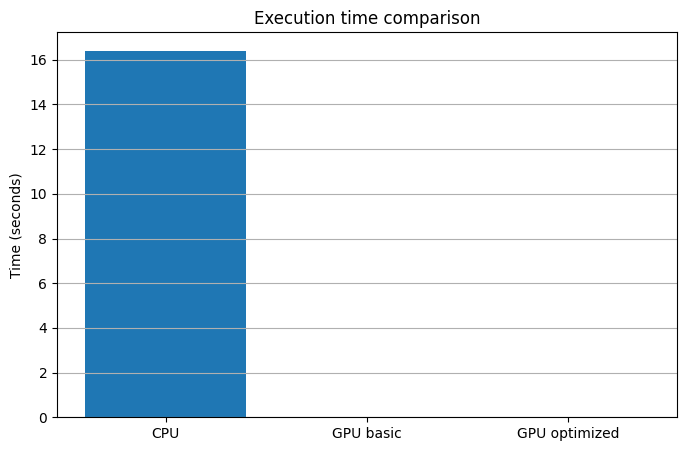

In [25]:
labels = ["CPU", "GPU basic", "GPU optimized"]
times = [cpu_time, gpu_basic_time, gpu_opt_time]

plt.figure(figsize=(8, 5))
plt.bar(labels, times)

plt.title("Execution time comparison")
plt.ylabel("Time (seconds)")
plt.grid(axis="y")

plt.show()